# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SehrishEjaz1/Flyrank_ML_Intern/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [11]:
import os, subprocess

if not os.path.exists("Flyrank_ML_Intern"):
    subprocess.run(["git", "clone", "https://github.com/SehrishEjaz1/Flyrank_ML_Intern.git"])

os.chdir("Flyrank_ML_Intern")
print("Current dir:", os.getcwd())

Current dir: /content/Flyrank_ML_Intern/Flyrank_ML_Intern/Flyrank_ML_Intern/Flyrank_ML_Intern


In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import json, os, warnings
warnings.filterwarnings("ignore")

SEED = 42

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
df["avg_position"]  = df["avg_position"].replace(0, np.nan)
df["has_wordcount"] = df["word_count"].notna().astype(int)
df["word_count"]    = df["word_count"].fillna(0)

features = ["days_since_last_update", "impressions_90d", "ctr",
            "avg_position", "content_age_days", "word_count", "has_wordcount"]

np.random.seed(SEED)
clients = df["client_id"].unique()
np.random.shuffle(clients)
split = int(len(clients) * 0.8)
train = df[df["client_id"].isin(clients[:split])].copy()
test  = df[df["client_id"].isin(clients[split:])].copy()

X_train = train[features].fillna(0)
y_train = train["is_declining_label"]
X_test  = test[features].fillna(0)
y_test  = test["is_declining_label"]

rf = RandomForestClassifier(n_estimators=100, max_depth=6,
                             random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_scores = rf.predict_proba(X_test)[:,1]

lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(X_train, y_train)
lr_scores = lr.predict_proba(X_test)[:,1]

ctr_median = train["ctr"].median()
stale   = (test["days_since_last_update"] >= 180).astype(int)
visible = (test["impressions_90d"] >= 500).astype(int)
low_ctr = (test["ctr"] < ctr_median).astype(int)
baseline_scores = stale * visible * (1 + low_ctr) * test["impressions_90d"]

def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

base_rate  = y_test.mean()
p_baseline = precision_at_k(baseline_scores, y_test)
p_lr       = precision_at_k(lr_scores, y_test)
p_rf       = precision_at_k(rf_scores, y_test)

print(f"Base rate:    {base_rate:.3f}")
print(f"Baseline P@50: {p_baseline:.3f}")
print(f"LR P@50:       {p_lr:.3f}")
print(f"RF P@50:       {p_rf:.3f}")

Base rate:    0.531
Baseline P@50: 0.500
LR P@50:       0.280
RF P@50:       0.720


## 1. Question

*The research question and the decision it supports.*

Research question:
Which web pages should a content team review first to address
observed traffic decline?

Decision it supports:
A content editor needs to prioritize which pages to update each week.
Reviewing all pages is not feasible — this work produces a ranked queue
so editor time goes to pages with the strongest observed decline signals.

The output is decision-support, not an automated verdict.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Source: FlyRank ML Internship starter dataset
File: data/raw/content_refresh_anonymized.csv
Size: 30,000 rows × 44 columns
Clients: 32 pseudonymized clients
Window: trailing 90-day snapshot

What was excluded and why:
- avg_position = 0 rows: excluded from position-based signals
  (0 means no data, not rank zero)
- trend_direction and trend_pct: excluded as features
  (label is derived from these — using them would be leakage)
- content_id and client_id: excluded as features
  (pseudonyms for grouping only, not signals)
- Pages with < 200 impressions: marked skip in action queue
  (too little traffic to justify editor time)

Public-safe: no client names, URLs, or raw queries appear anywhere.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Label definition:
is_declining_label = 1 when trend_direction == "down"
This is a proxy label derived from a rule on the same snapshot —
not a directly observed future outcome.

Features used (7 total):
- days_since_last_update: content staleness
- impressions_90d: traffic visibility
- ctr: click-through rate (already in % — 0.76 means 0.76%)
- avg_position: average search ranking
- content_age_days: how old the content is
- word_count: content length
- has_wordcount: missingness flag (some content types have no word count)

Baseline (Week 4):
Hand-written rule: stale × visible × (1 + low_ctr) × impressions
Reason codes: STALE_LOW_CTR, STALE_VISIBLE, NOT_STALE

Models trained:
- Logistic Regression (readable, probability scores for ranking)
- Random Forest (captures signal combinations, permutation importance)

Validation design:
Client-grouped split — 80% clients train, 20% clients test.
No page from a test client appears in training.
This tests generalization to unseen clients.

Leakage checks:
- trend_direction and trend_pct confirmed excluded
- Leaky feature test run: adding trend_pct inflates score → confirms exclusion correct
- No future windows used — all features from same 90-day snapshot

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Metric: Precision@50 on client-grouped test split.
Same split, same metric as Week-4 baseline.
Base rate printed next to every number.

In [13]:
print("=== Results vs Baseline ===\n")
results = pd.DataFrame({
    "Method": ["Base rate (random)", "Rule baseline (W04)",
                "Logistic Regression", "Random Forest"],
    "Precision@50": [base_rate, p_baseline, p_lr, p_rf],
    "vs Baseline": [base_rate - p_baseline,
                    0.0,
                    p_lr - p_baseline,
                    p_rf - p_baseline]
})
print(results.to_string(index=False))

=== Results vs Baseline ===

             Method  Precision@50  vs Baseline
 Base rate (random)      0.531468     0.031468
Rule baseline (W04)      0.500000     0.000000
Logistic Regression      0.280000    -0.220000
      Random Forest      0.720000     0.220000


## 5. Limitations

*What this work cannot claim.*

What this work cannot claim:

1. Causation: refreshing a page will NOT guaranteed increase traffic.
   The data is a cross-sectional snapshot — no intervention was measured.

2. Generalization: results are from 32 pseudonymized clients in one
   90-day window. Performance on new clients or different time periods
   may differ.

3. Label quality: is_declining_label is a proxy from trend_direction —
   not a directly observed future traffic outcome.

4. Algorithm changes: a major Google update can shift all signals.
   The model should be retrained after any such event.

5. SERP effects: low CTR may reflect SERP layout (featured snippets,
   ads) rather than content quality — a refresh may not help.

Honest framing:
"These pages show observed decline signals in this dataset.
The ranked list is a starting point for human review —
not a guarantee of traffic recovery."

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Top actions from the content action playbook:

Priority 1 — STALE_LOW_CTR:
Pages not updated in 180+ days with CTR below median.
Strongest observed decline signal. Review content relevance and
update with current information and better title/meta.

Priority 2 — HIGH_POSITION:
Pages ranking below position 20 with stale content.
Content may no longer match search intent. Review and restructure.

Priority 3 — STALE_VISIBLE:
Pages with good impressions but stale content.
Monitor for one month — refresh only if CTR starts dropping.

Skip — LOW_TRAFFIC or NOT_STALE:
Not worth editor time now.

Human review required before any action:
- Confirm page is not under active campaign
- Check CMS for recent edits not yet indexed
- Verify content is still strategically relevant

Never automate:
- Publishing content changes from score alone
- Deleting or redirecting pages without sign-off

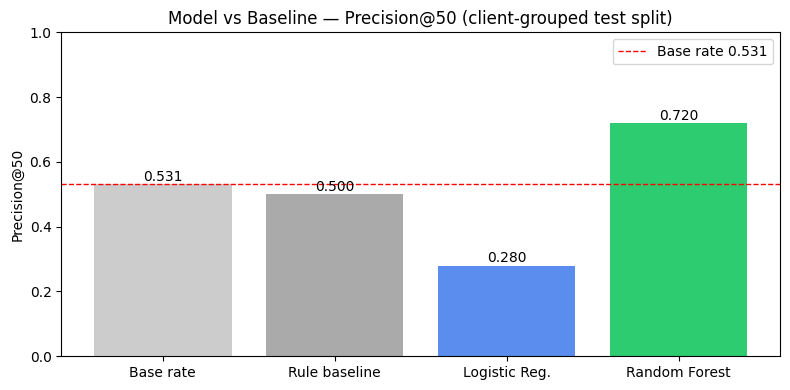

Saved: work/figures/model_comparison.png


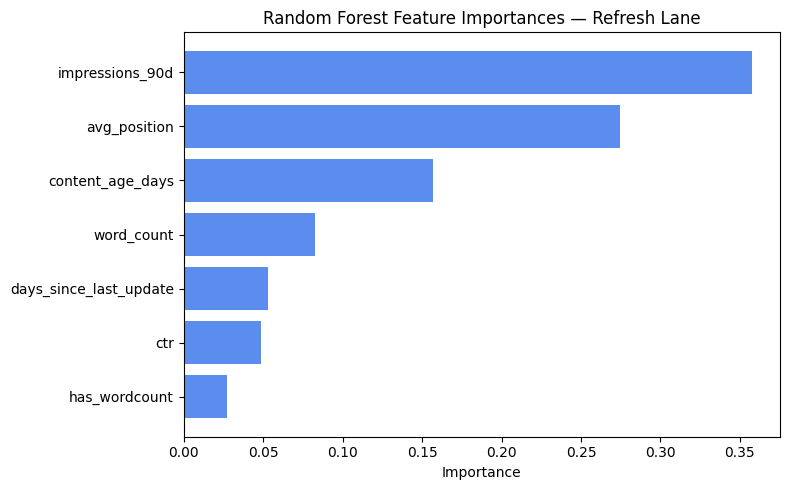

Saved: work/figures/feature_importance.png


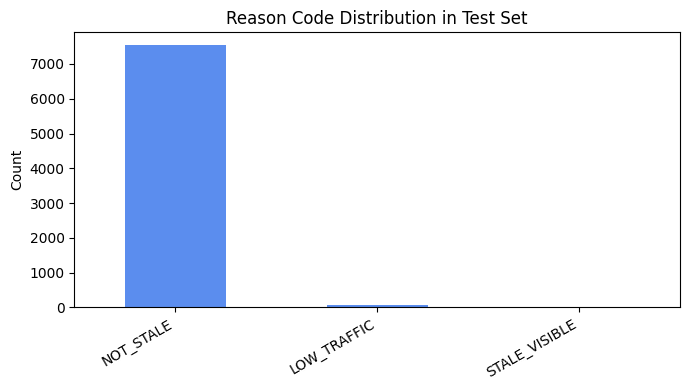

Saved: work/figures/reason_codes.png

Metrics: {
  "base_rate": 0.5315,
  "precision_at_50_baseline": 0.5,
  "precision_at_50_lr": 0.28,
  "precision_at_50_rf": 0.72,
  "test_rows": 7611,
  "train_clients": 25,
  "test_clients": 7,
  "seed": 42
}


In [14]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Figure 1: Model comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4))
methods = ["Base rate", "Rule baseline", "Logistic Reg.", "Random Forest"]
scores  = [base_rate, p_baseline, p_lr, p_rf]
colors  = ["#cccccc", "#aaaaaa", "#5b8dee", "#2ecc71"]
bars = ax.bar(methods, scores, color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel("Precision@50")
ax.set_title("Model vs Baseline — Precision@50 (client-grouped test split)")
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{score:.3f}", ha="center", fontsize=10)
ax.axhline(base_rate, color="red", linestyle="--",
           linewidth=1, label=f"Base rate {base_rate:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/model_comparison.png", dpi=150)
plt.show()
print("Saved: work/figures/model_comparison.png")

# Figure 2: Feature importance
imp_df = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1],
        color="#5b8dee")
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importances — Refresh Lane")
plt.tight_layout()
plt.savefig("work/figures/feature_importance.png", dpi=150)
plt.show()
print("Saved: work/figures/feature_importance.png")

# Figure 3: Reason code distribution
test2 = test.copy()
test2["rf_score"] = rf_scores

def assign_reason(row):
    if row["days_since_last_update"] < 180:
        return "NOT_STALE"
    elif row["impressions_90d"] < 200:
        return "LOW_TRAFFIC"
    elif row["ctr"] < ctr_median and row["impressions_90d"] >= 500:
        return "STALE_LOW_CTR"
    elif row["avg_position"] > 20:
        return "HIGH_POSITION"
    else:
        return "STALE_VISIBLE"

test2["reason_code"] = test2.apply(assign_reason, axis=1)
reason_counts = test2["reason_code"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
reason_counts.plot(kind="bar", ax=ax, color="#5b8dee")
ax.set_title("Reason Code Distribution in Test Set")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("work/figures/reason_codes.png", dpi=150)
plt.show()
print("Saved: work/figures/reason_codes.png")

# Save metrics JSON
metrics = {
    "base_rate": round(float(base_rate), 4),
    "precision_at_50_baseline": round(float(p_baseline), 4),
    "precision_at_50_lr": round(float(p_lr), 4),
    "precision_at_50_rf": round(float(p_rf), 4),
    "test_rows": len(test),
    "train_clients": len(clients[:split]),
    "test_clients": len(clients[split:]),
    "seed": SEED
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("\nMetrics:", json.dumps(metrics, indent=2))

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Figures exported to work/figures/:
- model_comparison.png — bar chart: model vs baseline Precision@50
- feature_importance.png — Random Forest feature importances
- reason_codes.png — reason code distribution in test set

Metrics exported to work/outputs/:
- capstone_metrics.json — all headline numbers (seed, P@50, base rate)

These files are what the deployed HTML paper embeds.
The queue CSV (action_playbook_queue.csv) stays out of git by design.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.